# Particle-Particle Particle-Mesh Algorithm

The Particle-Particle Particle-Mesh (PPPM or P3M) algorithm is a Fourier-based Ewald summation method formulated by Hockney and Eastwood in the late 1980s.

## Ewald Sum
The Ewald summation is a method to compute the potential energy of long-range interaction in periodic systems. More details can be found in this Wikipedia [article](https://en.wikipedia.org/wiki/Ewald_summation). In the following we will concentrate on explaining how it is used in the context of Sarkas.

Long range forces are calculated using the Ewald method which consists in dividing the potential into a short
and a long range part. Physically this is equivalent to adding and subtracting a screening cloud around each charge.
This screening cloud is usually chosen to be given by a Gaussian charged density distribution, but it need not be.
The primary reason for choosing a Gaussian is its spherical symmetry. In the following we will calculate the charge density with its surrounding clouds and the corresponding energy density of each.

### Total charge density
Consider a system of $N$ randomly distributed charges whose distribution is given by

$$ \rho_N ( \mathbf r) = \sum_{i = 1}^{N} q_i \delta( \mathbf r - \mathbf r_i). $$

At each point $\mathbf r_i$ we add and substract a Gaussian screening cloud 

$$ \rho_S (\mathbf r) = -\frac{q_i \alpha^{3/2}}{\pi} e^{-\alpha^2 (\mathbf r - \mathbf r_i)^2}. $$

The total charge density at point $\mathbf r$ is then

$$
\rho(\mathbf r) = \sum_{i}^N  \left \{ \left ( q_i\delta( \mathbf r - \mathbf r_i) - \frac{q_i\alpha^{3/2}}{\pi} e^{-\alpha^2 \left( \mathbf r - \mathbf r_i \right )^2 } \right ) + \frac{q_i\alpha^{3/2}}{\pi} e^{-\alpha^2 \left( \mathbf r- \mathbf r_i \right )^2 } \right \},
$$

where, again, the first term is the charge density due to the real particles and the last two terms are the negative
and positive screening clouds. The first two terms are in parenthesis to emphasizes the splitting into

$$
    \rho(\mathbf r)  = \rho_{\mathcal R}(\mathbf r) + \rho_{\mathcal F}(\mathbf r)
$$

$$
    \rho_{\mathcal R} (\mathbf r) = \sum_{i}^N \left ( q_i\delta( \mathbf r- \mathbf r_i) - \frac{q_i\alpha^{3/2}}{\pi} e^{-\alpha^2 \left( \mathbf r- \mathbf r_i \right )^2 } \right ), \quad \rho_{\mathcal F}(\mathbf r) = \sum_{i}^N \frac{q_i\alpha^{3/2}}{\pi} e^{-\alpha^2 \left( \mathbf r- \mathbf r_i \right )^2 }
$$

where $\rho_{\mathcal R}(\mathbf r)$ indicates the charge density leading to the short range part of the potential
and $\rho_{\mathcal F}(\mathbf r)$ leading to the long range part. The subscripts $\mathcal R, \mathcal F$ stand for Real and Fourier space indicating the way the calculation will be done.

The potential at every point $\mathbf r$ is calculated from Poisson's equation

$$
    -\nabla^2 \phi( \mathbf r) = 4\pi \rho_{\mathcal R} (\mathbf r) + 4\pi \rho_{\mathcal F}( \mathbf r).
$$

### Short-range term

The short range term is calculated in the usual way

$$
    -\nabla^2 \phi_{\mathcal R}( \mathbf r) = 4\pi \sum_{i}^N  \left ( q_i\delta( \mathbf r- \mathbf r_i) - \frac{q_i\alpha^{3/2}}{\pi} e^{-\alpha^2 \left( \mathbf r- \mathbf r_i \right )^2 } \right ).
$$

The first term $\delta(\mathbf r - \mathbf r_i)$ leads to the usual Coulomb potential ($\sim 1/r$) while
the Gaussian leads to the error function

$$
    \phi_{\mathcal R}( \mathbf r ) = \sum_i^N  \frac{q_i}{r} - \frac{q_i}{r}\text{erf} (\alpha r)  = \sum_i^N \frac{q_i}{r} \text{erfc}(\alpha r)
$$ (eq:phi_R)

### Long-range term

The long range term is calculated in Fourier space

$$
    k^2 \tilde\phi_{\mathcal F}(k) = 4\pi \tilde\rho_{\mathcal F}(k)
$$

where

$$
    \tilde\rho_{\mathcal F}(k) = \frac{1}{V} \int d\mathbf re^{- i \mathbf k \cdot \mathbf r} \rho_{\mathcal F}( \mathbf r ) = \sum_{i}^N \frac{q_i\alpha^{3/2}}{\pi V} \int d\mathbf r e^{- i \mathbf k \cdot \mathbf r}  e^{-\alpha^2 \left( \mathbf r - \mathbf r_i \right )^2 } = \sum_{i}^N \frac{q_i}{V} e^{-i \mathbf k \cdot \mathbf r_i} e^{-k^2/(4\alpha^2)}.
$$

The potential is then

$$
    \tilde \phi_{\mathcal F}(\mathbf k) = \frac{4\pi}{k^2} \frac{1}{V} \sum_{i}^N q_i e^{-i\mathbf k \cdot \mathbf r_i} e^{-k^2/(4\alpha^2)} = \frac{1}{V} \sum_i^N v(k)e^{-k^2/(4 \alpha^2)} q_i e^{-i \mathbf k \cdot \mathbf r_i}
$$

and in real space

$$
    \sum_{\mathbf k \neq 0} \tilde \phi_{\mathcal F}(\mathbf k)e^{i \mathbf k \cdot \mathbf r} = \frac{1}{V} \sum_{\mathbf k\neq 0} \sum_{i}^N v(k) e^{-k^2/(4\alpha^2)}q_i e^{i \mathbf k \cdot ( \mathbf r- \mathbf r_i) },
$$(eq:U_R)

where the $\mathbf k = 0$ is removed from the sum because of the overall charge neutrality.

The potential energy created by this long range part is

$$
    U_{\mathcal F} = \frac {1}{2} \sum_i^N q_i \phi_{\mathcal F}(\mathbf r_i) = \frac{1}{2} \frac{1}{V} \sum_{i,j}^N q_i q_j \sum_{\mathbf k \neq 0 } v(k)  e^{-k^2/(4\alpha^2)}e^{i \mathbf k \cdot ( \mathbf r_i - \mathbf r_j) } = \frac{1}{2} \sum_{\mathbf k \neq 0} |\rho_0(\mathbf k)|^2 v(k) e^{-k^2/(4\alpha^2)},
$$ (eq:U_F)

where I used the definition of the charge density

$$
    \rho_0(\mathbf k) = \frac 1V \sum_i^N q_i e^{i \mathbf k \cdot \mathbf r_i}.
$$

However, in the above sum we are including the self-energy term, i.e. $\mathbf r_i = \mathbf r_j$. This term
can be easily calculated and then removed from $U_{\mathcal F}$

$$
    \frac{\mathcal Q^2}{2V} \sum_{\mathbf k} \frac{4\pi}{k^2} e^{-k^2/(4\alpha^2)} \rightarrow \frac{\mathcal Q^2}{2V} \left ( \frac{L}{2\pi} \right )^3 \int dk (4\pi)^2 e^{-k^2/(4\alpha^2) }  = \mathcal Q^2 \frac{(4\pi)^2}{2V} \left ( \frac{L}{2\pi} \right )^3 \sqrt{\pi } \alpha = \mathcal Q^2 \frac{\alpha}{\sqrt{\pi} }
$$

where $\mathcal Q^2 = \sum_i^N q_i^2$, note that in the integral we have re-included $\mathbf k = 0$, but
this is not a problem. Finally the long-range potential energy is

$$
    U_{\mathcal L} = U_{\mathcal F} - \mathcal Q^2 \frac{\alpha}{\sqrt{\pi} }.
$$ (eq:phi_L)

Up to this point we have the analytical expression for our potential; {eq}`eq:U_R` and {eq}`eq:U_F`. However, computing the sum over $\mathbf k$ in the equation for $U_{\mathcal F}$ is still too slow and we don't know what value of $\mathbf k$ to end the sum.


## Assigning charges onto the mesh
The idea of particle-mesh algorithms is to speed up the calculation of the reciprocal (space) potential $U_{\mathcal F}$ by calculating it on a mesh. However, the particles are scattered at random points in space so we need to distribute them onto the mesh points. For simplicity, we assume the number of grid points $M$ to be identical in all three directions $M = M_x = M_y = M_z$. Define the spacing between two grid points $h = L/M$ and $\mathbb{M}$ the set of all grid points:

$$
    \mathbb{M} = \left \{ \mathbf mh \; : \mathbf m \in \mathbb{Z}^3 \; \textrm{and} \; 0 \leq m_{x,y,z} < M \right \}.
$$

The charge density of the mesh, $\rho_M(\mathbf r)$, is calculated by

$$
    \rho_{M}(\mathbf r) = \int U_p(\mathbf r - \mathbf r') \rho(\mathbf r') d\mathbf r', \quad U_p(\mathbf r) = h^{-3} W_p(\mathbf r), \quad  \mathbf r \in \mathbb{M}
$$

where $W_p(\mathbf r)$ is the charge assignment function of order $p \in \mathbb{N}^+$. In Sarkas we chose it to be a cardinal B-spline with a Fourier transform

$$
    \tilde W_{p}(\mathbf k) = h^3 \left [ \frac{\sin(k_xh/2)}{k_x h/2} \frac{\sin(k_y h/2)}{k_y h/2} \frac{\sin(k_z h/2)}{k_z h/2} \right ]^p.
$$

Substituting the above into $\rho_M(\mathbf r)$ we find

$$
    \rho_M (\mathbf r) = \int d\mathbf r' h^{-3} W( \mathbf r - \mathbf r')\sum_{i} q_i \delta(\mathbf r' - \mathbf r_i), = h^{-3} \sum_{i} q_i  W( \mathbf r - \mathbf r_i).
$$

except at the boundaries where the periodicity has to be properly taken into account.

The routine to deposit charges onto the grid is the following,

1. Assume the particle is at position $x_i$.
2. Choose the charge assignment order $p$,
3. Find the coordinate of the closest mesh point to the particle's location, if $p$ is odd. If $p$ is even take the coordinate of the midpoint of between the two nearest mesh points. Denote this by $x_m$
4. Find the $p$ mesh points that are closest to the particle, starting from the far left.
5. The fraction of charge to be deposited on each point is given by $W_p(x_i - x_m)$.

In the following we show a 1D example by calculating $W_p(x)$ for two particles each with a different $p$. We position the particles near the edges to show the periodic boundary conditions.

## Code 1: Charge Assignment Functions in 1D


In [1]:
# Import the usual stuff
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

plt.style.use("MSUstyle")

# Random number generator
rng = np.random.default_rng(123456789)

from sarkas.potentials.force_pm import assgnmnt_func, calc_charge_dens, mesh_point_shift, calc_mesh_coord

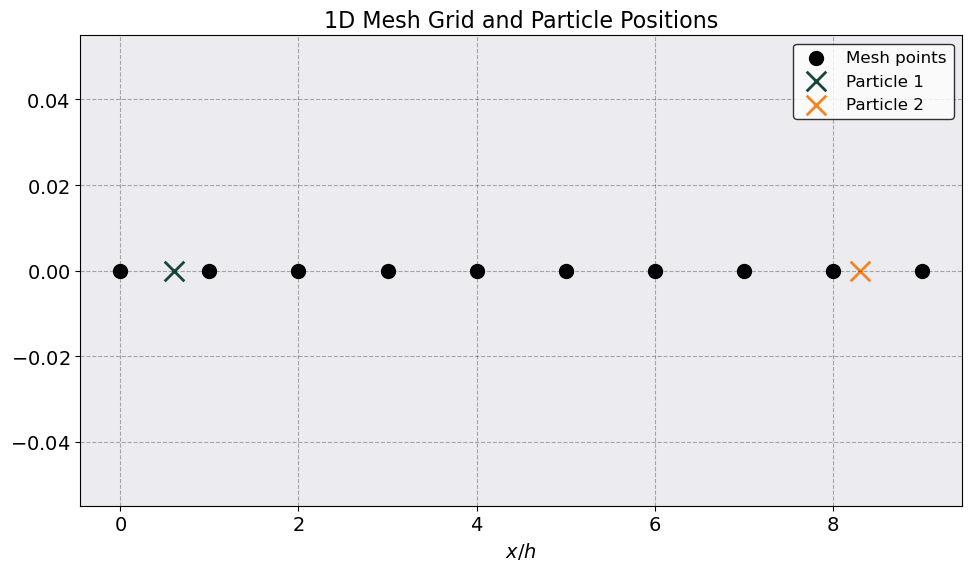

In [2]:
# Part 1: Understanding Charge Assignment Functions in 1D
# ======================================================

# 1.1 - Setup the mesh grid and particle positions
x_1 = 0.6  # Position of particle 1
x_2 = 8.3  # Position of particle 2
N_mesh_points = 10  # Number of mesh points
x_mesh = np.arange(0, N_mesh_points)  # Grid points
hx = x_mesh[1] - x_mesh[0]  # Grid spacing (chosen to be 1)

# Visualize the mesh grid and particles
plt.figure(figsize=(10, 6))
plt.scatter(x_mesh, np.zeros_like(x_mesh), c='k', s=100, label="Mesh points")
plt.scatter(x_1, 0, s=200, marker='x', label="Particle 1")
plt.scatter(x_2, 0, s=200, marker='x', label="Particle 2")
plt.legend(fontsize=12)
plt.xlabel(r"$x/h$", fontsize=14)
plt.title("1D Mesh Grid and Particle Positions", fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The above plot shows the position of the two particles, represented by X's and the location of the mesh points, represented by black dots. Notice that we are rescaling everything by the distance between mesh points, $h$, which we choose to be = 1 for simplicity.

The next code cell calculates the function $W(x)$ which represents the amount of charge to be assigned to each mesh point. Particle 1 is distributed over three points while Particle 2 over four mesh points.

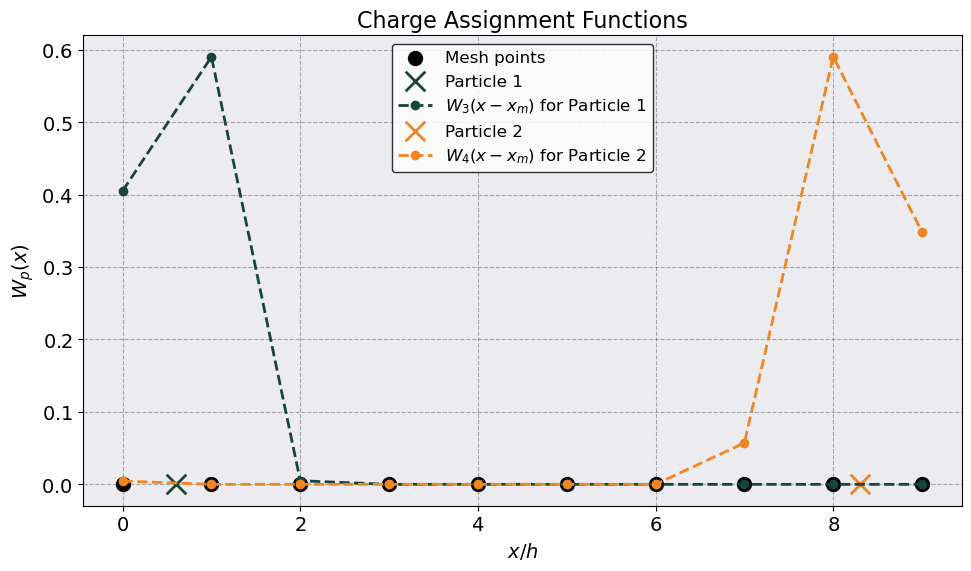

Particle 1 (CAO=3) assignment weights: [0.405 0.59  0.005]
Sum of weights for Particle 1: 1.0

Particle 2 (CAO=4) assignment weights: [0.05716667 0.59016667 0.34816667 0.0045    ]
Sum of weights for Particle 2: 1.0


In [3]:
# 1.2 - Calculate the charge assignment functions
# Define the charge assignment order for each particle
cao1 = 3  # Charge assignment order for particle 1
cao2 = 4  # Charge assignment order for particle 2

# Calculate nearest mesh point indices
# If cao is odd, round to nearest grid point
# If cao is even, round to nearest midpoint between grid points
x_m1 = np.rint(x_1/hx - 0.5 * (cao1 % 2 == 0)).astype(int)
x_m2 = np.rint(x_2/hx - 0.5 * (cao2 % 2 == 0)).astype(int)

# Calculate distance to the reference point
# For odd cao: distance to nearest mesh point
# For even cao: distance to midpoint between nearest mesh points
delta_x1 = x_1/hx - (x_m1 + 0.5 * (cao1 % 2 == 0))
delta_x2 = x_2/hx - (x_m2 + 0.5 * (cao2 % 2 == 0))

# Calculate assignment weights using the assignment function
# This returns an array of length = cao with weight for each affected grid point
wx1 = assgnmnt_func(cao1, delta_x1)
wx2 = assgnmnt_func(cao2, delta_x2)

# 1.3 - Map the weights to the full grid, accounting for periodic boundaries
full_wx1 = np.zeros(len(x_mesh))
full_wx2 = np.zeros(len(x_mesh))

# For particle 1 (cao=3)
mid1, pshift1 = mesh_point_shift(np.array([cao1]))
ixn = x_m1 - pshift1[0]  # First mesh point that gets charge
for ix in range(cao1):
    # Handle periodic boundary conditions
    index = ixn % N_mesh_points  # Simpler way to handle periodic BCs
    full_wx1[index] = wx1[ix]
    ixn += 1
    
# For particle 2 (cao=4)
mid2, pshift2 = mesh_point_shift(np.array([cao2]))
ixn = x_m2 - pshift2[0]  # First mesh point that gets charge
for ix in range(cao2):
    # Handle periodic boundary conditions
    index = ixn % N_mesh_points  # Simpler way to handle periodic BCs
    full_wx2[index] = wx2[ix]
    ixn += 1



# 1.4 - Visualize the charge assignment functions
plt.figure(figsize=(10, 6))
plt.scatter(x_mesh, np.zeros_like(x_mesh), s=100, label="Mesh points", c='k')

# Plot particle 1 and its assignment function
p1 = plt.scatter(x_1, 0, s=200, marker='x', label="Particle 1", )
plt.plot(x_mesh, full_wx1, '--o', label=f"$W_{cao1}(x - x_m)$ for Particle 1")

# Plot particle 2 and its assignment function
p2 = plt.scatter(x_2, 0, s=200, marker='x', label="Particle 2", )
plt.plot(x_mesh, full_wx2, '--o', label=f"$W_{cao2}(x - x_m)$ for Particle 2")

# Add sum of both assignment functions to show additive nature
# plt.plot(x_mesh, full_wx1 + full_wx2, ls='--', c='green', label=f"Sum of both assignment functions")

plt.legend(fontsize=12)
plt.ylabel(r"$W_p(x)$", fontsize=14)
plt.xlabel(r"$x/h$", fontsize=14)
plt.title("Charge Assignment Functions", fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 1.5 - Display the assignment function values
print("Particle 1 (CAO=3) assignment weights:", wx1)
print("Sum of weights for Particle 1:", np.sum(wx1))
print("\nParticle 2 (CAO=4) assignment weights:", wx2)
print("Sum of weights for Particle 2:", np.sum(wx2))

As you can see the first (orange) particle is distributed on the three mesh points (9, 0, 1) while the second (green) particle onto the four mesh points (7, 8, 9, 0). 


### 2D Example

The algorithm described above can be extended to 3D and it is what is contained in the function [calc_charge_dens](../api/potentials_subpckg/sarkas.potentials.force_pm.rst). In the following we will present an example with randomly distributed charges on a 2D plane for visualization.


In [4]:
# System parameters
L = 64.0                           # System size
mesh_shape = np.array([16, 16])      # Number of mesh points in each dimension
mesh_spacing = L / mesh_shape        # Mesh spacing (h) in x and y
print(f"Mesh spacing: {mesh_spacing}")

# Create grid for visualization (optional)
xgrid, ygrid = np.mgrid[0:L:mesh_shape[0]*1j, 0:L:mesh_shape[1]*1j]

# -------------------------------
# 2. Particle and Assignment Parameters
# -------------------------------

# Particle parameters
particle_pos = np.array([[45.751, 45.751]])  # Particle position in 2D
particle_charge = np.array([1.0])           # Particle charge (unit charge)

print(f"Particle position: {particle_pos}")
# Charge assignment order (cao) in x and y
cao = np.array([3,3])

# -------------------------------
# 3. Compute Mesh Coordinates and Weights
# -------------------------------

# Compute the particle's position relative to the mesh and its nearest mesh point
mesh_pos, mesh_points = calc_mesh_coord(particle_pos, mesh_spacing, cao)
print(f"Mesh position: {mesh_pos}")
print(f"Nearest mesh point: {mesh_points}")

# Determine the midpoint shift and the shift to the nearest mesh point
mid, pshift = mesh_point_shift(cao)

# Compute the offsets (distance from the mesh point adjusted by midpoint)
delta_x = mesh_pos[0, 0] - (mesh_points[0, 0] + mid[0])
delta_y = mesh_pos[0, 1] - (mesh_points[0, 1] + mid[1])

# Compute the weight functions using the assignment function for each dimension
wx = assgnmnt_func(cao[0], delta_x)
wy = assgnmnt_func(cao[1], delta_y)

# -------------------------------
# 4. Spread Charge onto the Mesh
# -------------------------------

# Initialize the 2D charge density array (using mesh_shape, note: indices order is (x, y))
rho_2D = np.zeros((mesh_shape[1], mesh_shape[0]), dtype=np.float64)

# Determine the base indices for charge assignment with periodicity
base_ix = (mesh_points[0, 0] - pshift[0]) % mesh_shape[0]
base_iy = (mesh_points[0, 1] - pshift[1]) % mesh_shape[1]

# Loop over the support of the B-spline in x and y
for i in range(cao[0]):
    ix = (base_ix + i) % mesh_shape[0]  # Ensure periodic boundary in x
    for j in range(cao[1]):
        iy = (base_iy + j) % mesh_shape[1]  # Ensure periodic boundary in y
        # Add the weighted fraction of the charge at this mesh point
        rho_2D[iy, ix] += particle_charge[0] * wx[i] * wy[j]


Mesh spacing: [4. 4.]
Particle position: [[45.751 45.751]]
Mesh position: [[11.43775 11.43775]]
Nearest mesh point: [[11 11]]


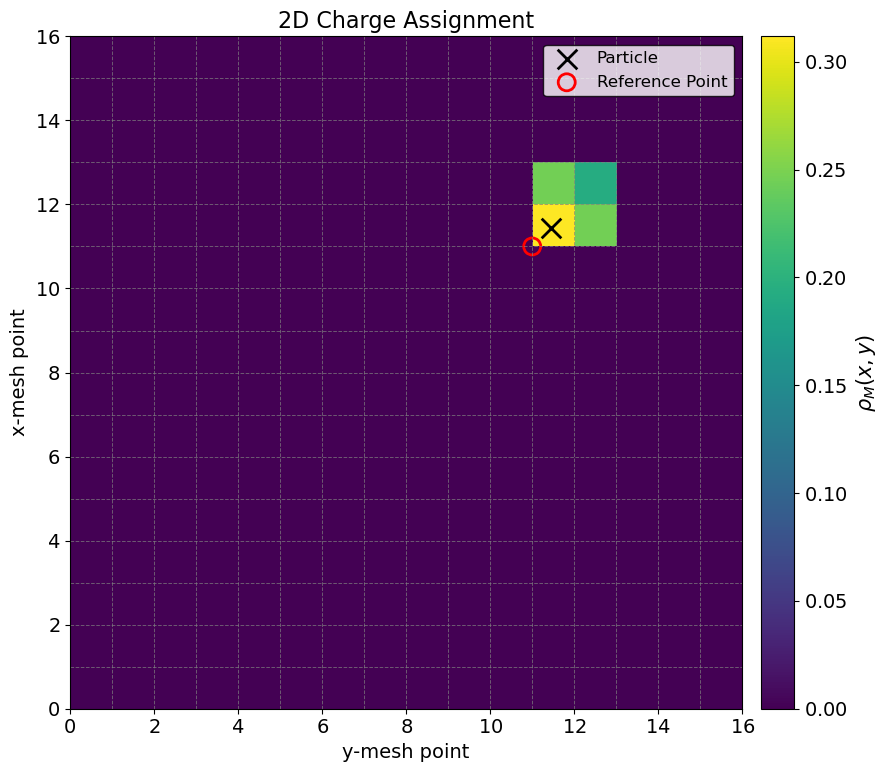

Total particle charge: 1.0
Total mesh charge: 1.0
Charge conservation error: 0.0


In [5]:
# Improved Visualization of the 2D Charge Density
plt.figure(figsize=(10, 8))

p1 = plt.imshow(rho_2D.T, origin='lower', extent=[0, L/mesh_spacing[1], 0, L/mesh_spacing[1]],
                 cmap = 'viridis', interpolation='nearest', )
plt.colorbar(p1, label=r"$\rho_M(x,y)$", pad=0.02)

# Draw mesh grid lines using the mesh spacing
for i in range(mesh_shape[0] + 1):
    plt.axhline(i , color='gray', linestyle='--', linewidth=0.7, alpha=0.7)
for j in range(mesh_shape[1] + 1):
    plt.axvline(j , color='gray', linestyle='--', linewidth=0.7, alpha=0.7)

# Mark the actual particle position
plt.scatter(particle_pos[0, 0]/ mesh_spacing[0], particle_pos[0, 1] / mesh_spacing[1], s=200, marker="x", c='black', label="Particle")

# Compute the reference point (nearest mesh point or midpoint) for clarity
x_ref = (mesh_points[0, 0] + mid[0]) # * mesh_spacing[0]
y_ref = (mesh_points[0, 1] + mid[1]) # * mesh_spacing[1]
plt.scatter(x_ref, y_ref, s=150, facecolors='none', edgecolors='red', linewidths=2,
            label="Reference Point")

# Add labels, legend, and title
plt.xlabel(r"y-mesh point", fontsize=14)
plt.ylabel(r"x-mesh point", fontsize=14)
plt.title("2D Charge Assignment", fontsize=16)
plt.legend(fontsize=12, loc='upper right')
plt.grid(False)
plt.tight_layout()
plt.show()

# Verify charge conservation
total_particle_charge = np.sum(particle_charge)
total_mesh_charge = np.sum(rho_2D)
charge_error = np.abs(total_particle_charge - total_mesh_charge)

print(f"Total particle charge: {total_particle_charge}")
print(f"Total mesh charge: {total_mesh_charge}")
print(f"Charge conservation error: {charge_error}")


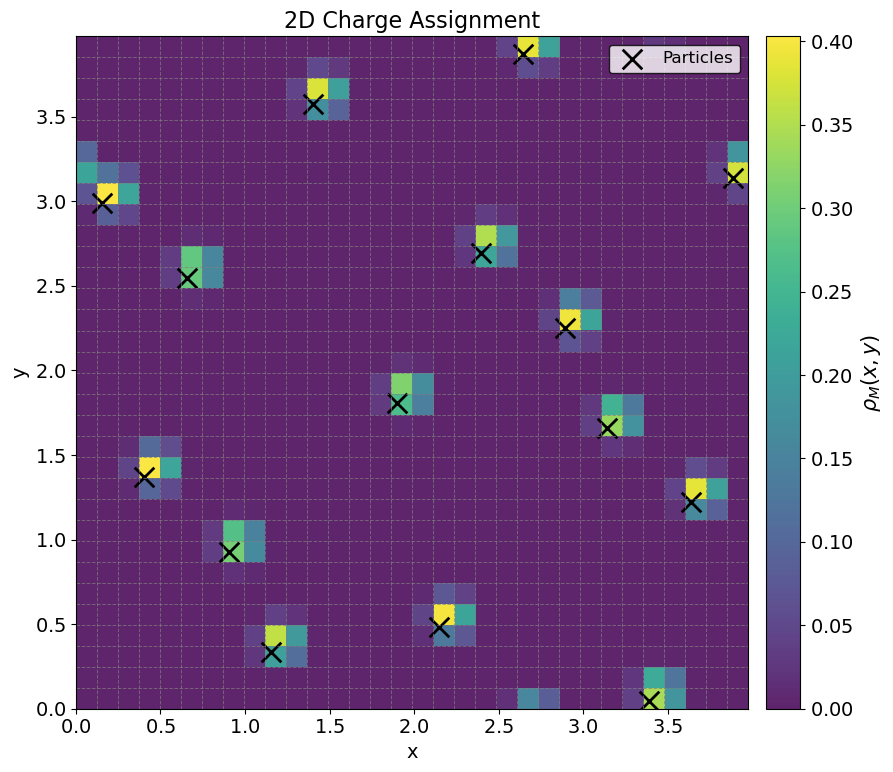

Total particle charge: 15.0
Total mesh charge: 14.999999999999998
Charge conservation error: 1.7763568394002505e-15


In [6]:
from scipy.stats.qmc import Halton

# Number of particles
N = 15
# Box length
L = (4* np.pi * N/3)**(1./3.)
box_lengths = np.ones(3) * L
box_lengths[2] = 0.0

# Charge assignment order
cao = np.array([4, 4, 1])
# Array of mesh points. Note in the case of 2D you still need to pass 1 for the z-mesh
M = 32
mesh_sz = np.array([M, M, 1])
xgrid, ygrid = np.mgrid[0:L:32j, 0:L:32j]

# Spacings
h_array = box_lengths/mesh_sz
h_array[2] = 0.0
# print(h_array)

# Particles positions
pos = Halton(3).random(N)
pos[:,0] *= L
pos[:,1] *= L
pos[:,2] = 0.0 # set the z-coord to 0

charges = np.ones( N, dtype = float)
# Calculate the charge density
mid, pshift = mesh_point_shift(cao)
mesh_pos, mesh_points = calc_mesh_coord(pos, h_array,cao)
rho_m = calc_charge_dens(mesh_pos, mesh_points, charges, cao, mesh_sz, mid, pshift)

# Visualize the charge density
plt.figure(figsize=(10, 8))
plt.imshow(rho_m[0,:,:], origin='lower', extent=[0, L, 0, L], alpha=0.85, cmap='viridis')
plt.colorbar(label=r"$\rho_M(x,y)$", pad=0.02)
plt.scatter(pos[:,0], pos[:,1], s=200, marker="x", c='black', label="Particles")

# add the mesh 
for i in range(mesh_sz[0] + 1):
    plt.axhline(i * h_array[0], color='gray', linestyle='--', linewidth=0.7, alpha=0.7)
    plt.axvline(i * h_array[1], color='gray', linestyle='--', linewidth=0.7, alpha=0.7)
    
plt.xlabel(r"x", fontsize=14)
plt.ylabel(r"y", fontsize=14)
plt.title("2D Charge Assignment", fontsize=16)
plt.legend(fontsize=12, loc='upper right')
plt.grid(False)
plt.tight_layout()
plt.show()

# Verify charge conservation
total_particle_charge = np.sum(charges)
total_mesh_charge = np.sum(rho_m)
charge_error = np.abs(total_particle_charge - total_mesh_charge)

print(f"Total particle charge: {total_particle_charge}")
print(f"Total mesh charge: {total_mesh_charge}")
print(f"Charge conservation error: {charge_error}")


The first thing to note is the shape of the charge density; it is ( z_mesh, y_mesh, x_mesh). This is a legacy feature that has not been removed. 

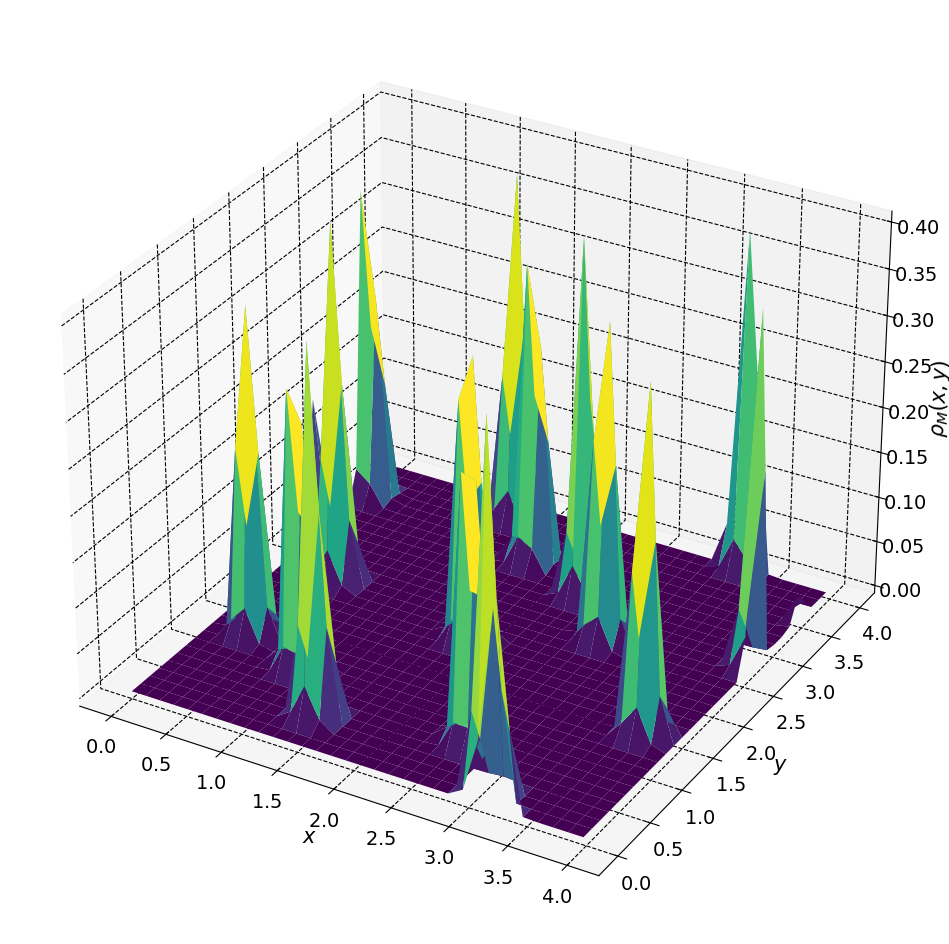

In [7]:
plt.rcParams["axes.facecolor"] = [1, 1, 1]
fig, ax = plt.subplots(figsize=(12, 12),subplot_kw={"projection": "3d"})

ax.plot_surface(xgrid, ygrid, rho_m[0], cmap = plt.cm.viridis)
# Uncomment the following if you want to see images of the rho_m duplicated.
# ax.plot_surface(xgrid - L, ygrid, rho_m[0].T, cmap = plt.cm.viridis)
# ax.plot_surface(xgrid - L, ygrid - L, rho_m[0].T, cmap = plt.cm.viridis)
# ax.plot_surface(xgrid , ygrid - L, rho_m[0].T, cmap = plt.cm.viridis)
# ax.plot_surface(xgrid , ygrid + L, rho_m[0].T, cmap = plt.cm.viridis)
# ax.plot_surface(xgrid + L , ygrid + L, rho_m[0].T, cmap = plt.cm.viridis)
# ax.plot_surface(xgrid + L , ygrid, rho_m[0].T, cmap = plt.cm.viridis)
# ax.plot_surface(xgrid + L , ygrid - L, rho_m[0].T, cmap = plt.cm.viridis)
# ax.plot_surface(xgrid - L , ygrid + L, rho_m[0].T, cmap = plt.cm.viridis)
_ = ax.set( xlabel = r"$x$", ylabel = r"$y$", zlabel = r"$\rho_M(x,y)$")

## Part 2. Potential, Electric field, and Virial Tensor

In [8]:
# reset the kernel
%reset -f

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy.stats.qmc import Halton

from sarkas.potentials.force_pm import (
    assgnmnt_func, 
    calc_charge_dens, mesh_point_shift, calc_mesh_coord,
    force_optimized_green_function, calc_pot_pm, FFTWObjects, update as pm_update
)
from sarkas.potentials.force_pp import (
    update as pp_update, 
    create_cells_array, 
    create_head_list_arrays, 
    particles_interaction_loop
)
from other import (
    assgnmnt_func as assgnmnt_func_other, 
    calc_charge_dens as calc_charge_dens_other, 
    mesh_point_shift as mesh_point_shift_other, 
    calc_mesh_coord as calc_mesh_coord_other, 
    force_optimized_green_function as force_optimized_green_function_other
    )

from sarkas.potentials.core import Potential
from sarkas.potentials.coulomb import coulomb_force_pppm, update_params, coulomb_force
from sarkas.utilities.maths import force_error_analytic_pp

# Setup simulation parameters
print("Setting up simulation parameters...")

# System size and mesh
dimensions = 2
total_num_ptcls = 10_000  # Total number of particles

L = (4.0 * np.pi * total_num_ptcls/3.0)**(1./3.)
box_lengths = np.ones(3) * L
if dimensions == 2:
    non_zero_dims = 2
    box_lengths[2] = 0.0  # Set z-length to zero for 2D system
else:
    non_zero_dims = 3

box_volume = L**non_zero_dims # Total volume

mesh_size = np.full(3, 32, dtype=np.int64)  # Number of mesh points in each dimension
if dimensions == 2:
    mesh_size[2] = 1  # Set z-mesh to 1 for 2D system
h_array = box_lengths / mesh_size  # Mesh spacing

mesh_volume = np.prod(h_array[:non_zero_dims])  # Volume of each mesh cell

# Create fftw objects for FFT optimization
fftw_objects = FFTWObjects(mesh_size, threads=1)  # Optimized FFT objects

#### Parameters for PPPM

# Charge assignment order
cao = np.full(3, 3, dtype=np.int64)
if dimensions == 2:
    cao[2] = 1  # Set z-cao to 1 for 2D system

# Cutoff radius for short-range interactions
rc = L/3  # Cutoff radius

# Ewald parameter alpha controls splitting between short/long range
alpha = 0.3 / h_array[0]  # Ewald parameter alpha

# Aliases for Green's function optimization
aliases = np.full(3, 3, dtype=np.int64)  # Use full aliasing for optimization
if dimensions == 2:
    aliases[2] = 0  # No aliasing in z-direction for 2D system


fourpie0 = 1.0  # 4πε₀ (set to 1 for simplicity)
# Constants for Coulomb potential
constants = np.array([0.0, alpha, fourpie0], dtype=np.float64)  # [kappa, alpha, 4πε₀]

# 3.4 - Calculate Green's function for PM part
print("\nCalculating optimized Green's function...")
G_k, kx_v, ky_v, kz_v, PM_err = force_optimized_green_function(
    box_lengths, h_array, mesh_size, aliases, cao, constants
)


print(f"System size: {L:.4f} x {L:.4f}")
print(f"Mesh: {mesh_size[0]} x {mesh_size[1]}")
print(f"Mesh spacing: {h_array[0]:.4f} x {h_array[1]:.4f}")
print(f"CAO: {cao[0]} x {cao[1]}")
print(f"Cutoff radius: {rc:.4f}")
print(f"Ewald parameter alpha: {alpha:.4f}")
print(f"rc * alpha: {rc * alpha:.4f}")


# Define particles
print("\nDefining particles...")
# Three particles: two positive and one negative
pos_qmc = Halton(dimensions, seed = 123456789).random(total_num_ptcls)
pos = np.zeros((total_num_ptcls, 3))
for i in range(dimensions):
    pos[:, i] = pos_qmc[:, i] * box_lengths[i]

pos[0, 0], pos[0, 1] = 8 * h_array[0], 8 * h_array[1]  # Place the first particle at a specific location for testing
pos[1, 0], pos[1, 1] = 24 * h_array[0], 24 * h_array[1]  # Place the second particle at a specific location for testing

vel = np.zeros_like(pos)  # Start with zero velocities

# Two species of particles: H and He 
num_species = 2
species_charges = np.array([2.0, 1.0], dtype=np.float64)
species_masses = np.array([4.0, 1.0], dtype=np.float64)

charges = np.array([species_charges[0] if i < total_num_ptcls//2 else species_charges[1] for i in range(total_num_ptcls)], dtype=np.float64)  # First half charge +1, second half charge +2
masses = np.array([species_masses[0] if i < total_num_ptcls//2 else species_masses[1] for i in range(total_num_ptcls)], dtype=np.float64)  # First half mass 1, second half mass 4
particle_ids = np.array([0 if i < total_num_ptcls//2 else 1 for i in range(total_num_ptcls)], dtype=np.int64)  # First half species 0, second half species 1

# Calculate charge density 
mid, pshift = mesh_point_shift(cao)
mesh_pos, mesh_points = calc_mesh_coord(pos, h_array, cao)

rho_m = calc_charge_dens(mesh_pos, mesh_points, charges, cao, mesh_size, mid, pshift)

# Check that the total charge is the same from rho_m and from the particle charges
print(f"Total charge from rho: {rho_m.sum():.6e}, from particles: {charges.sum():.6e}")

# Setup the potential matrix for the two species. This will be used in the PM part to calculate the potential and forces. 
# The first slice ([:,:,0]) is the Coulomb potential, and the second slice ([:,:,1]) is the Ewald splitting parameter alpha. 
# The third slice can be used for any additional parameters if needed.
potential_matrix = np.zeros((num_species, num_species, 3))

for i, q1 in enumerate(species_charges):
    for j, q2 in enumerate(species_charges):
        potential_matrix[i, j, 0] = q1 * q2 / fourpie0

potential_matrix[:, :, 1] = alpha


Setting up simulation parameters...

Calculating optimized Green's function...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


System size: 34.7293 x 34.7293
Mesh: 32 x 32
Mesh spacing: 1.0853 x 1.0853
CAO: 3 x 3
Cutoff radius: 11.5764
Ewald parameter alpha: 0.2764
rc * alpha: 3.2000

Defining particles...
Total charge from rho: 1.500000e+04, from particles: 1.500000e+04


Total charge from rho: 1.500000e+04, from particles: 1.500000e+04


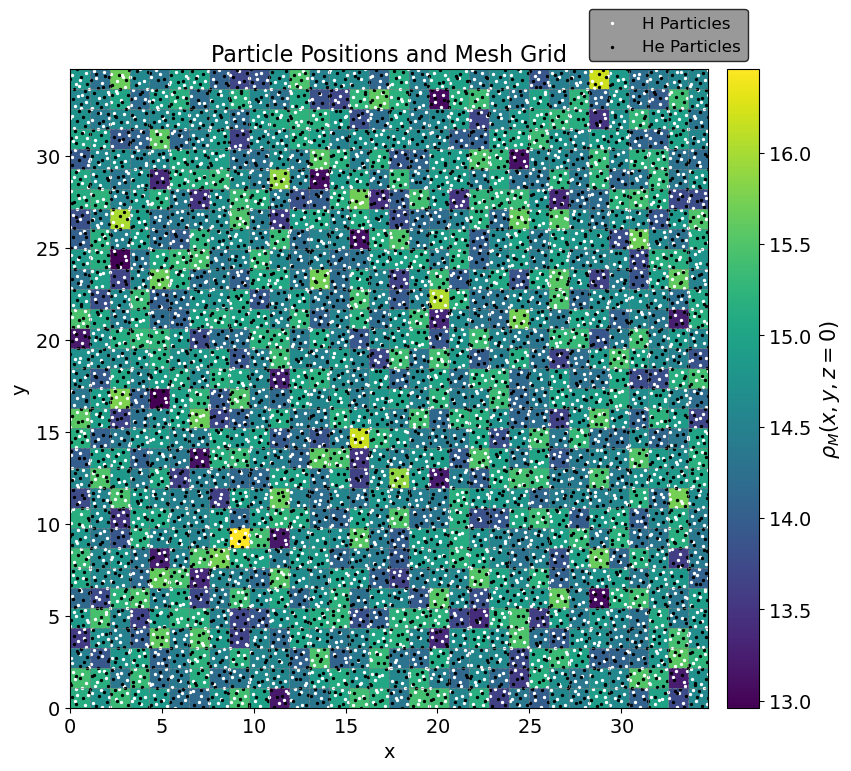

In [9]:
# Plot the particles positions and the charge density and the mesh
plt.figure(figsize=(10, 8))
plt.imshow(rho_m[0, :, :], origin='lower', extent=[0, L, 0, L], cmap='viridis')
plt.colorbar(label=r"$\rho_M(x,y,z = 0)$", pad=0.02)
# H particles
plt.scatter(pos[:total_num_ptcls//2, 0], pos[:total_num_ptcls//2, 1], s=2, marker="o", c='w', label="H Particles")
# He particles
plt.scatter(pos[total_num_ptcls//2:, 0], pos[total_num_ptcls//2:, 1], s=2, marker="o", c='k', label="He Particles")
plt.xlabel(r"x", fontsize=14)
plt.ylabel(r"y", fontsize=14)

# Draw mesh grid lines using the mesh spacing
for i in range(mesh_size[0] + 1):
    plt.axhline(i * h_array[0], color='gray', linestyle='--', linewidth=0.7, alpha=0.7)
    plt.axvline(i * h_array[1], color='gray', linestyle='--', linewidth=0.7, alpha=0.7)

plt.title("Particle Positions and Mesh Grid", fontsize=16)
# put legend outside the plot
plt.legend(fontsize=12, bbox_to_anchor=(.80, 1.), 
           facecolor='gray', edgecolor='black',)
plt.grid(False)
plt.tight_layout()


print(f"Total charge from rho: {rho_m.sum():.6e}, from particles: {charges.sum():.6e}")


In [10]:
from numpy.fft import fftshift, ifftshift
from pyfftw import empty_aligned

# Calculate the potential and electric fields using FFT
rho_k_fft = empty_aligned((mesh_size[2], mesh_size[1], mesh_size[0]), dtype=complex)
fftw_objects.forward_transform(rho_m, rho_k_fft)

# Shift the DC value at the center of the ndarray
rho_k = fftshift(rho_k_fft)

rho_k_real = rho_k.real
rho_k_imag = rho_k.imag
rho_k_sq = rho_k_real * rho_k_real + rho_k_imag * rho_k_imag

# Potential from Poisson eq.
phi_k = G_k * rho_k

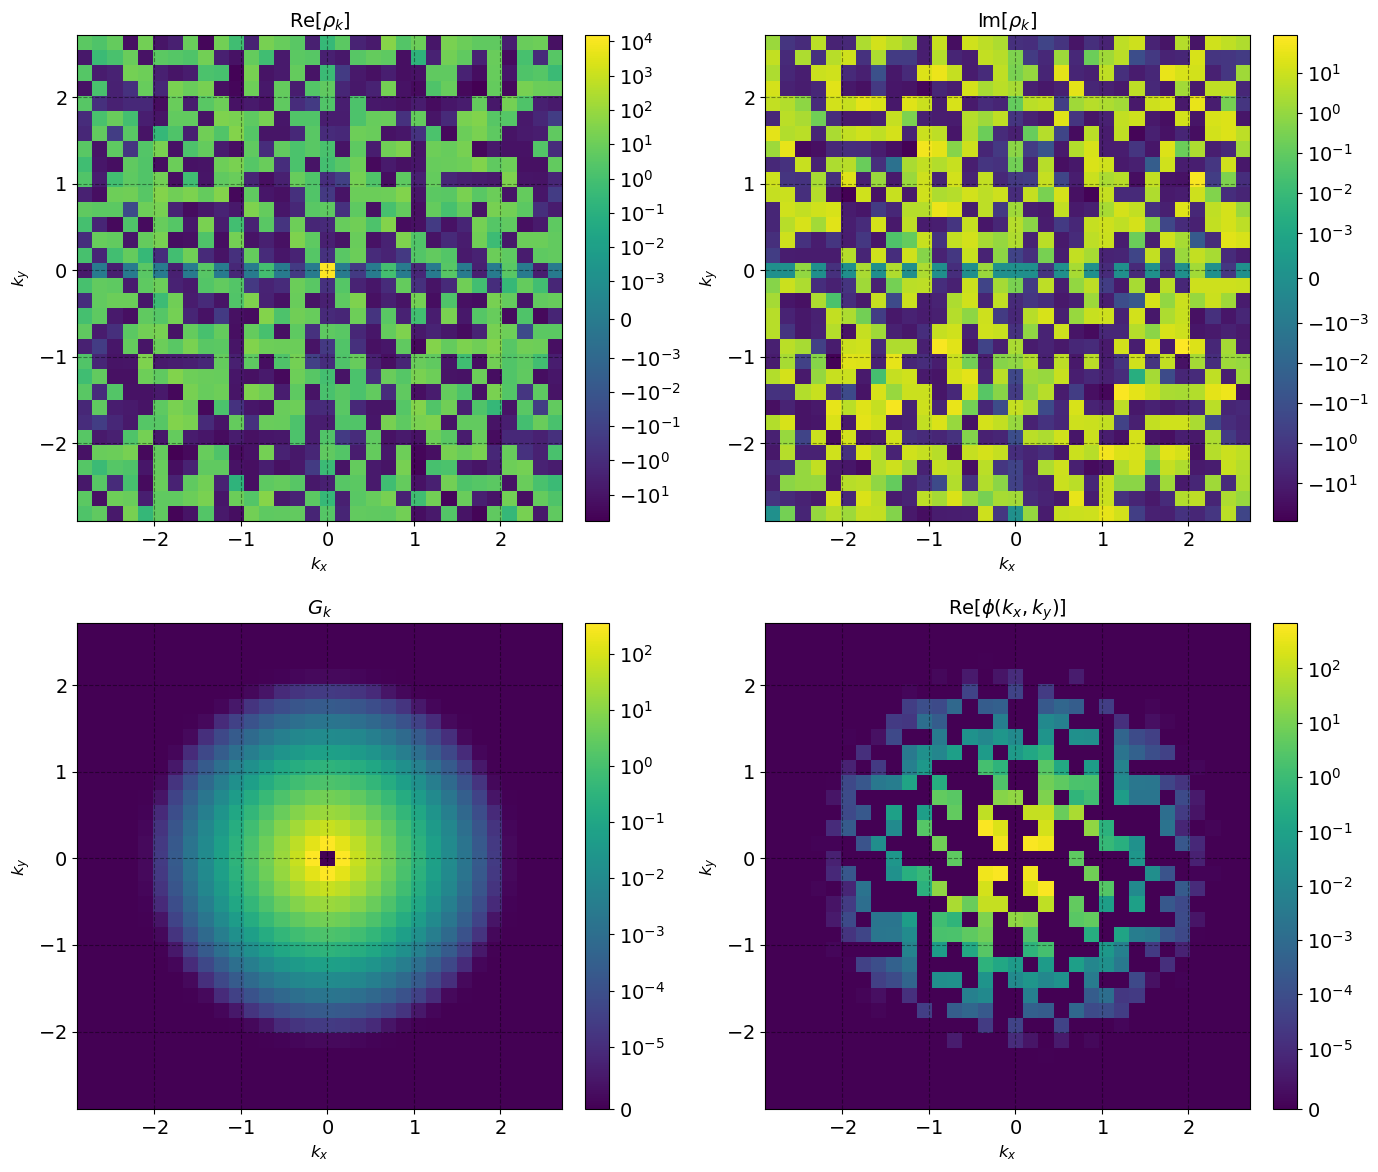

In [11]:
# Plot the rho_k and G_k to see how they behave in k-space
fig, ax = plt.subplots(2, 2, figsize=(14, 12))
im1 = ax[0, 0].imshow(rho_k.real[0], origin='lower', extent=[kx_v.min(), kx_v.max(), ky_v.min(), ky_v.max()], 
                      cmap='viridis', 
                      norm = mpl.colors.SymLogNorm(linthresh=1e-3, vmin=rho_k.real[0].min(), vmax=rho_k.real[0].max())
                      )
ax[0, 0].set_title(r"${\text{Re}}[\rho_k]$", fontsize=14)
ax[0, 0].set_xlabel(r"$k_x$", fontsize=12)
ax[0, 0].set_ylabel(r"$k_y$", fontsize=12)
plt.colorbar(im1, ax=ax[0, 0], fraction=0.046, pad=0.04)
im1 = ax[0, 1].imshow(rho_k.imag[0], origin='lower', extent=[kx_v.min(), kx_v.max(), ky_v.min(), ky_v.max()], 
                      cmap='viridis',
                      norm = mpl.colors.SymLogNorm(linthresh=1e-3, vmin=rho_k.imag[0].min(), vmax=rho_k.imag[0].max())
                      )
ax[0, 1].set_title(r"${\text{Im}}[\rho_k]$", fontsize=14)
ax[0, 1].set_xlabel(r"$k_x$", fontsize=12)
ax[0, 1].set_ylabel(r"$k_y$", fontsize=12)
plt.colorbar(im1, ax=ax[0, 1], fraction=0.046, pad=0.04)
p2 = ax[1, 0].imshow(G_k[0], origin='lower', extent=[kx_v.min(), kx_v.max(), ky_v.min(), ky_v.max()], 
                     cmap='viridis',
                      norm = mpl.colors.SymLogNorm(linthresh=1e-5, vmin=G_k[0].min(), vmax=G_k[0].max())
                      )
plt.colorbar(p2, ax=ax[1, 0], fraction=0.046, pad=0.04)
ax[1, 0].set_title(r"$G_k$", fontsize=14)
ax[1, 0].set_xlabel(r"$k_x$", fontsize=12)
ax[1, 0].set_ylabel(r"$k_y$", fontsize=12)
p2 = ax[1, 1].imshow(phi_k.real[0], origin='lower', extent=[kx_v.min(), kx_v.max(), ky_v.min(), ky_v.max()],
                      cmap='viridis',
                       norm = mpl.colors.SymLogNorm(linthresh=1e-5, vmin=np.abs(phi_k).min(), vmax=np.abs(phi_k).max())
                       )
plt.colorbar(p2, ax=ax[1, 1], fraction=0.046, pad=0.04)
ax[1, 1].set_title(r"${\text{Re}}[\phi(k_x, k_y)]$", fontsize=14)
ax[1, 1].set_xlabel(r"$k_x$", fontsize=12)
ax[1, 1].set_ylabel(r"$k_y$", fontsize=12)
plt.tight_layout()

In [12]:
# Calculate the potential energy of each particle
phi_r_cmplx = empty_aligned(phi_k.shape, dtype=complex)
# Perform the backward FFT to get the potential in real space
fftw_objects.backward_transform(ifftshift(phi_k), phi_r_cmplx)
phi_r = phi_r_cmplx.real / mesh_volume


Total potential energy from FFT: 4.9786e+01
Total potential energy from particles: 1.0242e+04
Error: 1.0192e+04


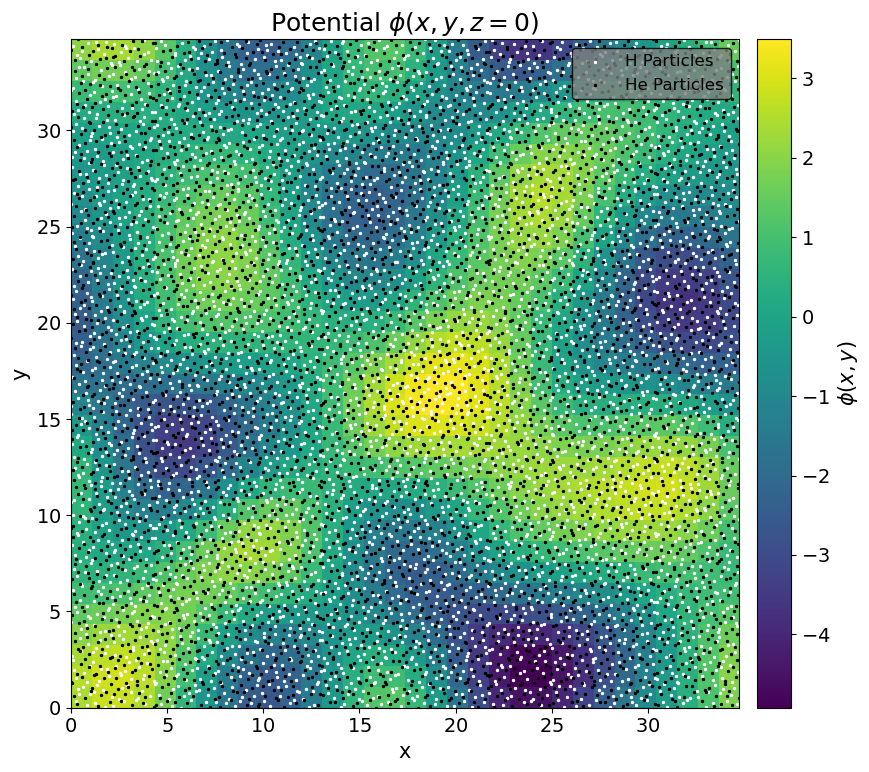

In [13]:
# Plot phi_r
fig, ax = plt.subplots(figsize=(10, 8))
p1 = ax.imshow(phi_r[0], origin='lower', extent=[0, L, 0, L], cmap='viridis')
plt.colorbar(p1, label=r"$\phi(x,y)$", pad=0.02)
# H particles
ax.scatter(pos[:total_num_ptcls//2, 0], pos[:total_num_ptcls//2, 1], s=2, marker="o", c='w', label="H Particles")
# He particles
ax.scatter(pos[total_num_ptcls//2:, 0], pos[total_num_ptcls//2:, 1], s=2, marker="o", c='k', label="He Particles")
ax.grid(False)
ax.legend(fontsize=12, loc='upper right', facecolor='gray', edgecolor='black',)
ax.set(xlabel=r"x", ylabel=r"y", title=r"Potential $\phi(x,y,z = 0)$")
plt.tight_layout()


phi_r2 = np.sqrt( phi_r_cmplx * phi_r_cmplx.conj() ).real / mesh_volume
# Potential of each particle
pot_particle = calc_pot_pm(phi_r2, mesh_pos, mesh_points, charges, cao, mesh_size, mid, pshift)

# Total potential energy
U_f = 0.5 * (rho_k_sq * G_k).sum() / box_volume

# Total potential energy of the particles
U_p = pot_particle.sum()

# Compare
print(f"Total potential energy from FFT: {U_f:.4e}")
print(f"Total potential energy from particles: {U_p:.4e}")
print(f"Error: {np.abs(U_p - U_f):.4e}")


In [14]:
from sarkas.potentials.force_pm import calc_field, calc_acc_pm

# Calculate the electric field from the potential
E_kx, E_ky, E_kz = calc_field(phi_k, kx_v, ky_v, kz_v)

# Prepare for fft. Shift the DC value back to its original position that is [0, 0, 0]
E_kx_unsh = ifftshift(E_kx)
E_ky_unsh = ifftshift(E_ky)
E_kz_unsh = ifftshift(E_kz)

E_x = empty_aligned(E_kx.shape, dtype=complex)
E_y = empty_aligned(E_ky.shape, dtype=complex)
E_z = empty_aligned(E_kz.shape, dtype=complex)
# Compute the electric fields using the reusable FFTW objects
fftw_objects.backward_transform(E_kx_unsh, E_x)
fftw_objects.backward_transform(E_ky_unsh, E_y)
fftw_objects.backward_transform(E_kz_unsh, E_z)

# FFT normalization
E_x_r = E_x.real / mesh_volume
E_y_r = E_y.real / mesh_volume
E_z_r = E_z.real / mesh_volume

# Calculate the accelerations of the particles from the electric field
acc_pm = calc_acc_pm(E_x_r, E_y_r, E_z_r, mesh_pos, mesh_points, charges/masses, cao, mesh_size, mid, pshift)

In [15]:
acc_pm[0], acc_pm[total_num_ptcls//2]  # Print the acceleration of the first particle of each species for testing

(array([-0.1486111 ,  0.27148597,  0.        ]),
 array([0.58123104, 0.04656109, 0.        ]))

In [16]:
# acc_pm[0], acc_pm[total_num_ptcls//2]  # Print the acceleration of the first particle of each species for testing

# acc_2 = np.zeros((2, 3))  # Initialize an array to store the accelerations of two particles
# acc_2[0] = np.array([-6.9388939e-18,  6.9388939e-18,  0.0000000e+00])
# acc_2[1] = np.array([ 6.24500451e-17, -2.77555756e-17,  0.00000000e+00])

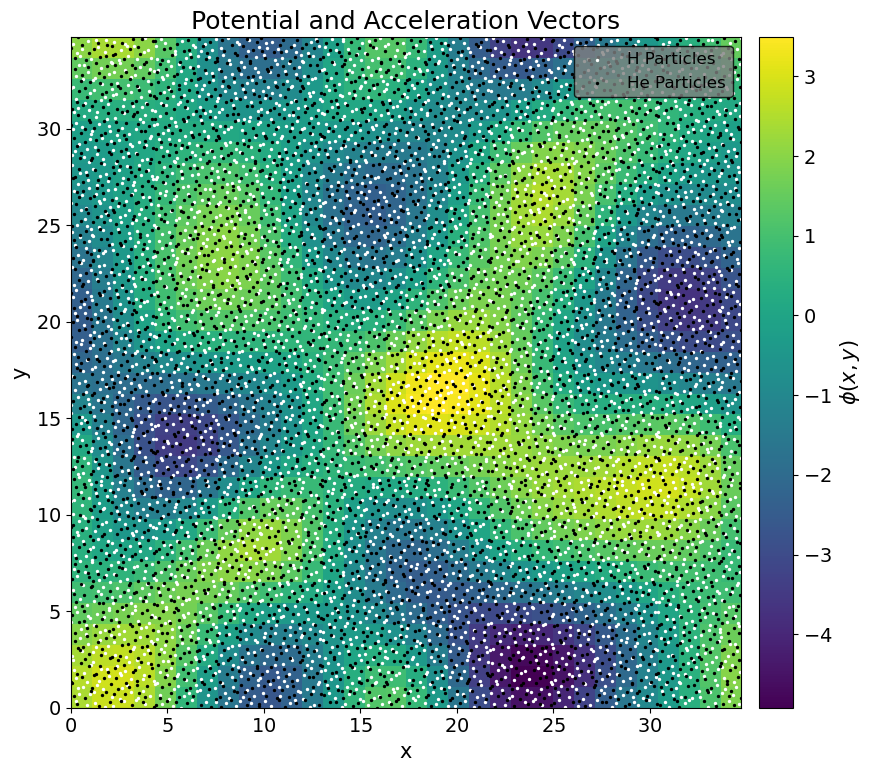

In [17]:
# Visualize the accelerations vectors on top of the potential
fig, ax = plt.subplots(figsize=(10, 8))
p1 = ax.imshow(phi_r[0], origin='lower', extent=[0, L, 0, L], cmap='viridis')
plt.colorbar(p1, label=r"$\phi(x,y)$", pad=0.02)
# H particles
ax.scatter(pos[:total_num_ptcls//2, 0], pos[:total_num_ptcls//2, 1], s=2, marker="o", c='w', label="H Particles")
# He particles
ax.scatter(pos[total_num_ptcls//2:, 0], pos[total_num_ptcls//2:, 1], s=2, marker="o", c='k', label="He Particles")
ax.grid(False)
ax.legend(fontsize=12, loc='upper right', facecolor='gray', edgecolor='black',)
ax.set(xlabel=r"x", ylabel=r"y", title=r"Potential and Acceleration Vectors")
plt.tight_layout()
# plt.savefig("potential_acceleration_2.png", dpi=300)

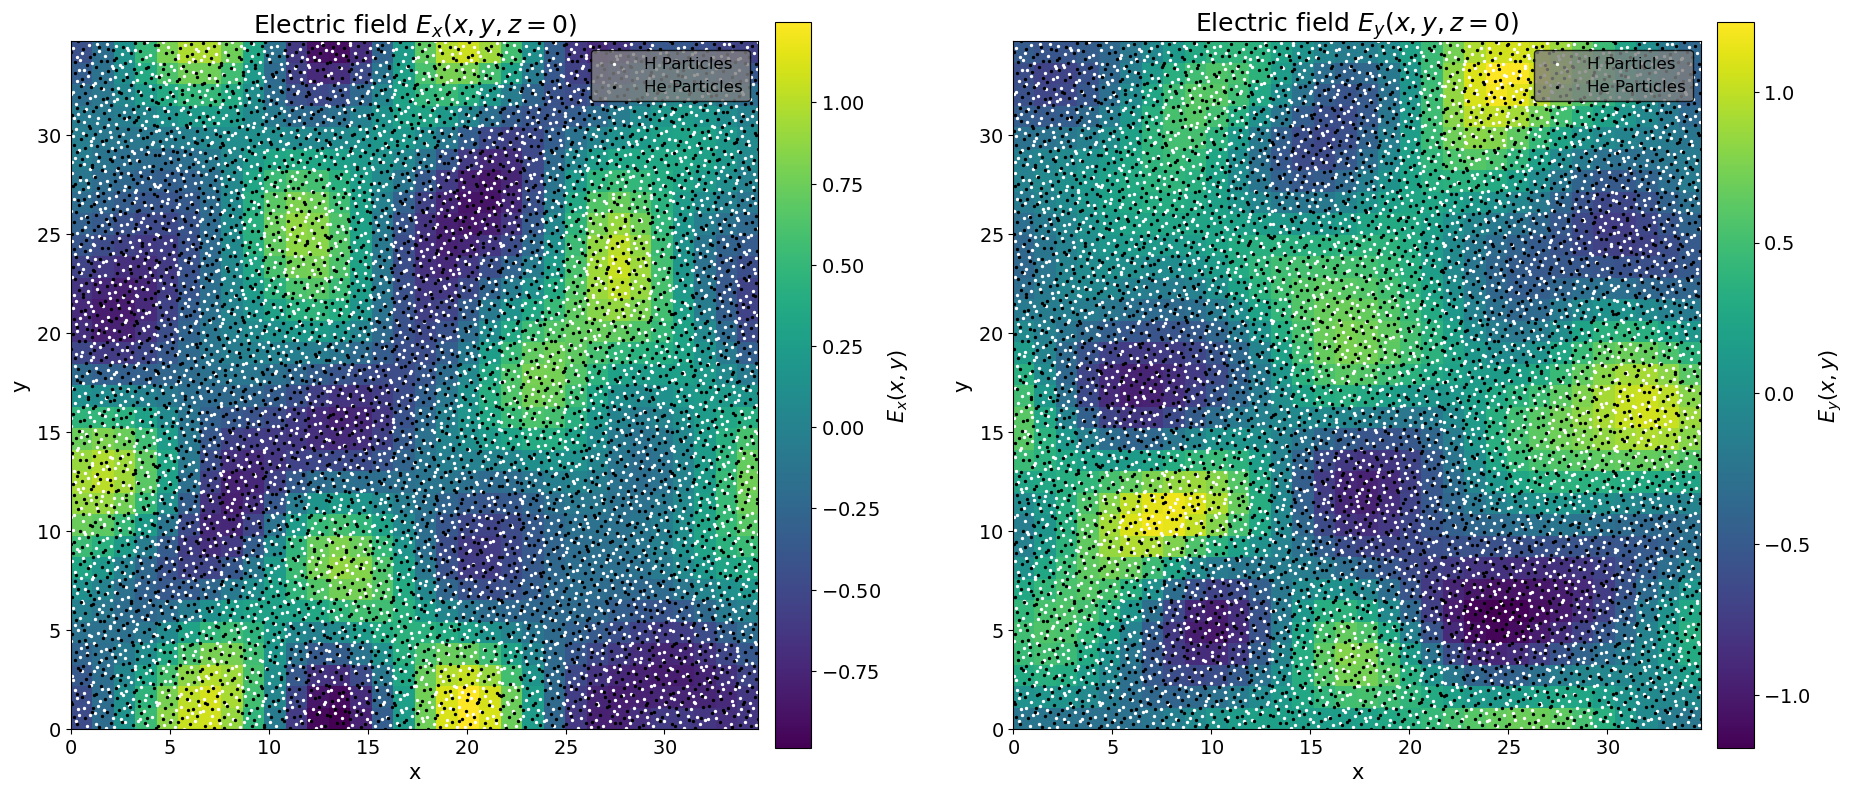

In [18]:
# Plot the electric field
fig, ax = plt.subplots(1, 2, figsize=(19, 8))
p1 = ax[0].imshow(E_x_r[0], origin='lower', extent=[0, L, 0, L], cmap='viridis')
plt.colorbar(p1, label=r"$E_{x}(x,y)$", pad=0.02)
# H particles
ax[0].scatter(pos[:total_num_ptcls//2, 0], pos[:total_num_ptcls//2, 1], s=2, marker="o", c='w', label="H Particles")
# He particles
ax[0].scatter(pos[total_num_ptcls//2:, 0], pos[total_num_ptcls//2:, 1], s=2, marker="o", c='k', label="He Particles")

ax[0].grid(False)
ax[0].set(xlabel=r"x", ylabel=r"y", title=r"Electric field $E_x(x,y,z = 0)$")

p2 = ax[1].imshow(E_y_r[0], origin='lower', extent=[0, L, 0, L], cmap='viridis')
plt.colorbar(p2, label=r"$E_{y}(x,y)$", pad=0.02)
# H particles
ax[1].scatter(pos[:total_num_ptcls//2, 0], pos[:total_num_ptcls//2, 1], s=2, marker="o", c='w', label="H Particles")
# He particles
ax[1].scatter(pos[total_num_ptcls//2:, 0], pos[total_num_ptcls//2:, 1], s=2, marker="o", c='k', label="He Particles")
ax[1].grid(False)
ax[1].set(xlabel=r"x", ylabel=r"y", title=r"Electric field $E_y(x,y,z = 0)$")       
for a in ax:
    a.legend(fontsize=12, loc='upper right', facecolor='gray', edgecolor='black',)
plt.tight_layout()


## Virial tensor

The virial tensor is a measure of the internal forces acting on a system of particles. It is defined as:

\begin{equation}
\mathcal W = \frac{1}{2} \sum_{i=1}^N \sum_{j\neq i}^N (\mathbf{r}_{ij} \otimes \mathbf{F}_{ij})
\end{equation}

where:
- $\mathcal W$ is the virial tensor
- $\mathbf{r}_{ij}$ is the position vector of particle i relative to particle j
- $\mathbf{F}_{ij}$ is the force vector acting on particle i due to particle j

The long range part of the virial tensor for each particle calculate as

\begin{equation}
\mathbf S_i = \frac{1}{2} q_i \mathbf s(\mathbf r_i)
\end{equation}

where:

$$ \mathbf s(\mathbf r_i) = \sum_{\mathbf r_m \in \mathbb{M} } \mathbf s(\mathbf r_m) W_{p}( \mathbf r_i - \mathbf r_m) $$
and $\mathbf s(\mathbf r)$ is the IFFT of $\mathbf {\tilde s}(\mathbf k)$, which is 

$$ \mathbf {\tilde s}(\mathbf k) = \frac{1}{2 V} G(\mathbf k) v(\mathbf k) \rho_m(\mathbf k)$$

where $v(\mathbf k)$ are the virial coefficients defined as:

$$ v(\mathbf k) = \phi(k) \mathbf I + \frac{d\phi(k)}{dk} \frac{\mathbf k \otimes \mathbf k}{k} $$

which for the Yukawa potential, $\frac{4 \pi }{k^2 +\kappa^2}e^{- \frac{k^2 + \kappa^2}{4 \alpha^2}}$

$$ v(\mathbf k)_{xx} = \phi(k) \left[ 1 - 2\left (\frac{1}{k^2 + \kappa^2} + \frac{1}{4\alpha^2} \right ) \right ]k_x k_x $$
$$ v(\mathbf k)_{yy} = \phi(k)\left[ 1 - 2\left (\frac{1}{k^2 + \kappa^2} + \frac{1}{4\alpha^2} \right ) \right ]k_y k_y $$
$$ v(\mathbf k)_{zz} = \phi(k) \left[ 1 - 2\left (\frac{1}{k^2 + \kappa^2} + \frac{1}{4\alpha^2} \right ) \right ]k_z k_z $$
$$ v(\mathbf k)_{xy} = - 2 \phi(k)\left (\frac{1}{k^2 + \kappa^2} + \frac{1}{4\alpha^2} \right ) k_x k_y$$
$$ v(\mathbf k)_{xz} = - 2 \phi(k)\left (\frac{1}{k^2 + \kappa^2} + \frac{1}{4\alpha^2} \right ) k_x k_z$$
$$ v(\mathbf k)_{yz} = - 2 \phi(k) \left (\frac{1}{k^2 + \kappa^2} + \frac{1}{4\alpha^2} \right ) k_y k_z $$


In [19]:
# Virial tensor calculation
from sarkas.potentials.force_pm import calc_virial_coefficients, calc_virial_pm_per_particle

# Calculate the virial coefficients
vg0, vg1, vg2, vg3, vg4, vg5 = calc_virial_coefficients(
    kx_v, ky_v, kz_v, mesh_size, constants
)
virial_k_xx = phi_k * vg0
virial_r_xx = empty_aligned(virial_k_xx.shape, dtype=complex)
fftw_objects.backward_transform(ifftshift(virial_k_xx), virial_r_xx)
virial_r_xx = virial_r_xx.real / mesh_volume

virial_k_yy = phi_k * vg1
virial_r_yy = empty_aligned(virial_k_yy.shape, dtype=complex)
fftw_objects.backward_transform(ifftshift(virial_k_yy), virial_r_yy)
virial_r_yy = virial_r_yy.real / mesh_volume

virial_k_zz = phi_k * vg2
virial_r_zz = empty_aligned(virial_k_zz.shape, dtype=complex)
fftw_objects.backward_transform(ifftshift(virial_k_zz), virial_r_zz)
virial_r_zz = virial_r_zz.real / mesh_volume

virial_k_xy = phi_k * vg3
virial_r_xy = empty_aligned(virial_k_xy.shape, dtype=complex)
fftw_objects.backward_transform(ifftshift(virial_k_xy), virial_r_xy)
virial_r_xy = virial_r_xy.real / mesh_volume

virial_k_xz = phi_k * vg4
virial_r_xz = empty_aligned(virial_k_xz.shape, dtype=complex)
fftw_objects.backward_transform(ifftshift(virial_k_xz), virial_r_xz)
virial_r_xz = virial_r_xz.real / mesh_volume

virial_k_yz = phi_k * vg5
virial_r_yz = empty_aligned(virial_k_yz.shape, dtype=complex)
fftw_objects.backward_transform(ifftshift(virial_k_yz), virial_r_yz)
virial_r_yz = virial_r_yz.real / mesh_volume

virial_xx, virial_yy, virial_zz, virial_xy, virial_xz, virial_yz = calc_virial_pm_per_particle(
    virial_r_xx, virial_r_yy, virial_r_zz, virial_r_xy, virial_r_xz, virial_r_yz,
    mesh_size, mesh_pos, mesh_points, charges,
    cao, mid, pshift
)
# Note that the _xz and _yz components are zero, but they are calculated for completeness.


# Check the virial sum
for vr, vk, coord in zip(
    [virial_xx, virial_yy, virial_zz, virial_xy],
    [vg0, vg1, vg2, vg3],
    ["xx", "yy", "zz", "xy"]
):
    vr_sum = vr.sum()
    vk_sum = 0.5 * (rho_k_sq * G_k * vk).sum() / box_volume

    print(f"Virial {coord} sum from particles: {vr_sum:.4f}")
    print(f"Virial {coord} sum from FFT: {vk_sum.real:.4f}")
    print(f"Virial {coord} MAE: {np.abs(vr_sum - vk_sum.real):.4f}")
    print("-" * 50)


Virial xx sum from particles: -55.0791
Virial xx sum from FFT: -55.0791
Virial xx MAE: 0.0000
--------------------------------------------------
Virial yy sum from particles: -54.3989
Virial yy sum from FFT: -54.3989
Virial yy MAE: 0.0000
--------------------------------------------------
Virial zz sum from particles: 49.7856
Virial zz sum from FFT: 49.7856
Virial zz MAE: 0.0000
--------------------------------------------------
Virial xy sum from particles: 6.7510
Virial xy sum from FFT: 6.7510
Virial xy MAE: 0.0000
--------------------------------------------------


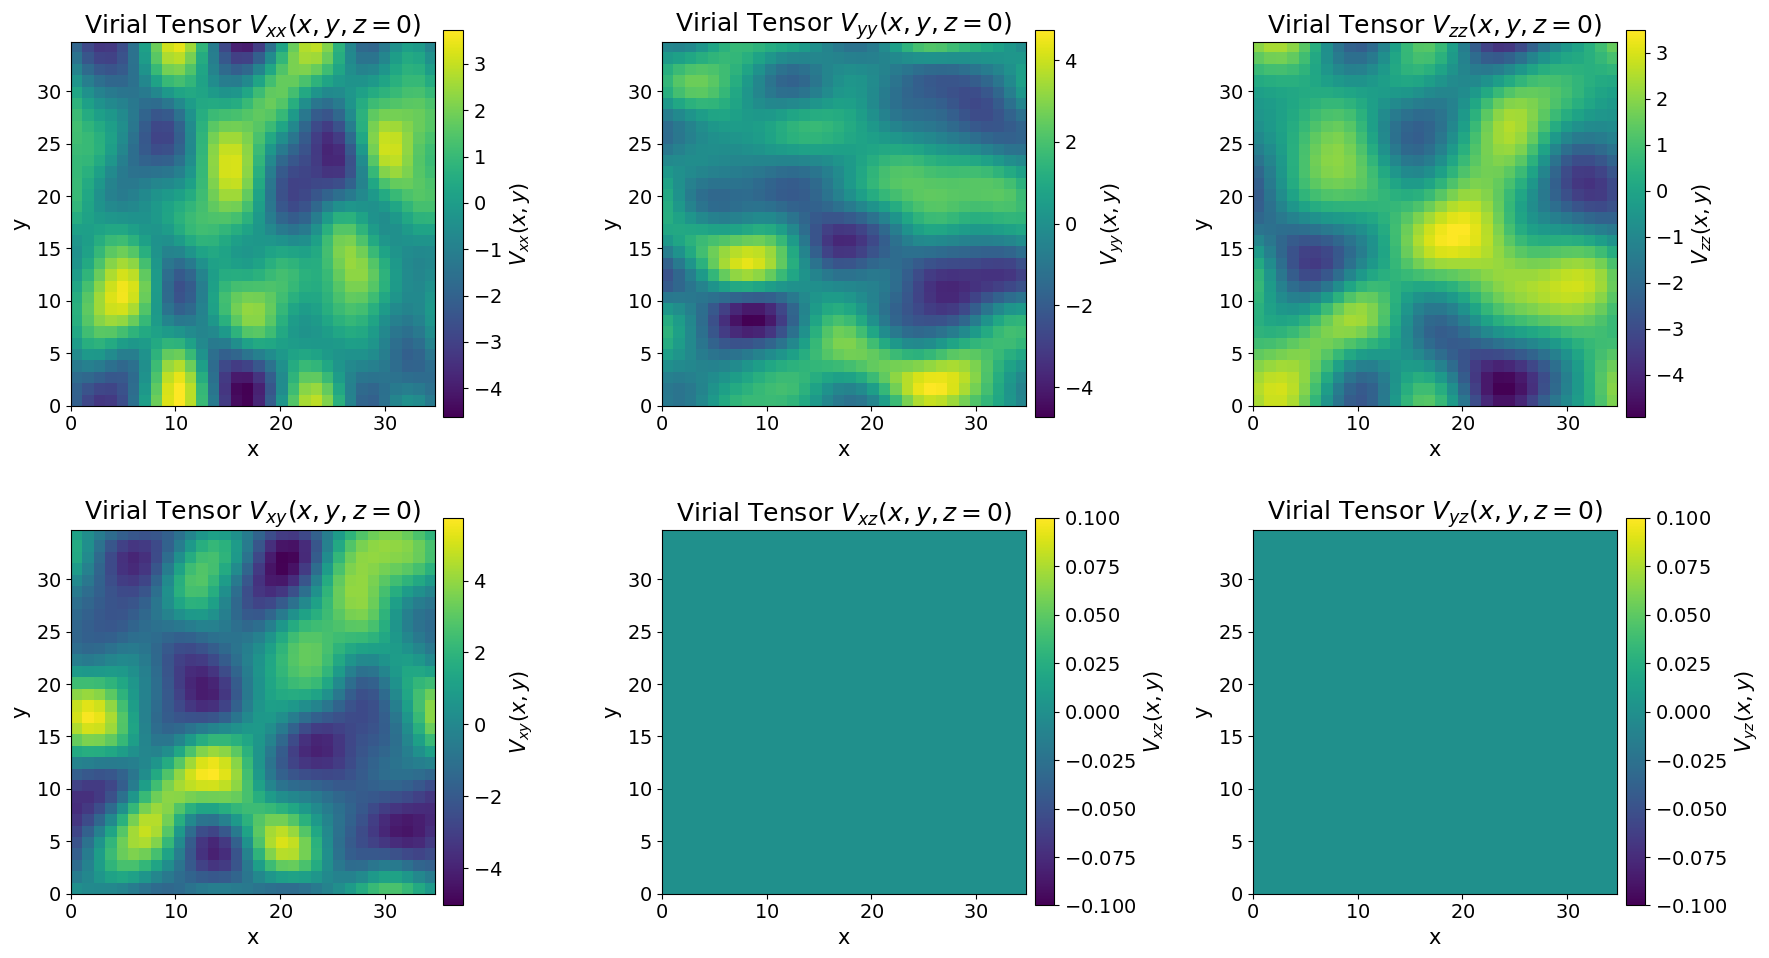

In [20]:
# Plot the virial tensor components
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
p1 = ax[0, 0].imshow(virial_r_xx[0], origin='lower', extent=[0, L, 0, L], cmap='viridis')
plt.colorbar(p1, label=r"$V_{xx}(x,y)$", pad=0.02)
ax[0, 0].set_title(r"Virial Tensor $V_{xx}(x,y,z = 0)$")
ax[0, 0].set(xlabel=r"x", ylabel=r"y")
ax[0, 0].grid(False)
p2 = ax[0, 1].imshow(virial_r_yy[0], origin='lower', extent=[0, L, 0, L], cmap='viridis')
plt.colorbar(p2, label=r"$V_{yy}(x,y)$", pad=0.02)
ax[0, 1].set_title(r"Virial Tensor $V_{yy}(x,y,z = 0)$")
ax[0, 1].set(xlabel=r"x", ylabel=r"y")
ax[0, 1].grid(False)
p3 = ax[0, 2].imshow(virial_r_zz[0], origin='lower', extent=[0, L, 0, L], cmap='viridis')
plt.colorbar(p3, label=r"$V_{zz}(x,y)$", pad=0.02)
ax[0, 2].set_title(r"Virial Tensor $V_{zz}(x,y,z = 0)$")
ax[0, 2].set(xlabel=r"x", ylabel=r"y")
ax[0, 2].grid(False)
p4 = ax[1, 0].imshow(virial_r_xy[0], origin='lower', extent=[0, L, 0, L], cmap='viridis')
plt.colorbar(p4, label=r"$V_{xy}(x,y)$", pad=0.02)
ax[1, 0].set_title(r"Virial Tensor $V_{xy}(x,y,z = 0)$")
ax[1, 0].set(xlabel=r"x", ylabel=r"y")
ax[1, 0].grid(False)
p5 = ax[1, 1].imshow(virial_r_xz[0], origin='lower', extent=[0, L, 0, L], cmap='viridis')
plt.colorbar(p5, label=r"$V_{xz}(x,y)$", pad=0.02)
ax[1, 1].set_title(r"Virial Tensor $V_{xz}(x,y,z = 0)$")
ax[1, 1].set(xlabel=r"x", ylabel=r"y")
ax[1, 1].grid(False)
p6 = ax[1, 2].imshow(virial_r_yz[0], origin='lower', extent=[0, L, 0, L], cmap='viridis')
plt.colorbar(p6, label=r"$V_{yz}(x,y)$", pad=0.02)
ax[1, 2].set_title(r"Virial Tensor $V_{yz}(x,y,z = 0)$")
ax[1, 2].set(xlabel=r"x", ylabel=r"y")
ax[1, 2].grid(False)    

plt.tight_layout()

PP error estimate: 2.216017e-41
PM error estimate: 7.060382e-05
Total error estimate: 7.060382e-05


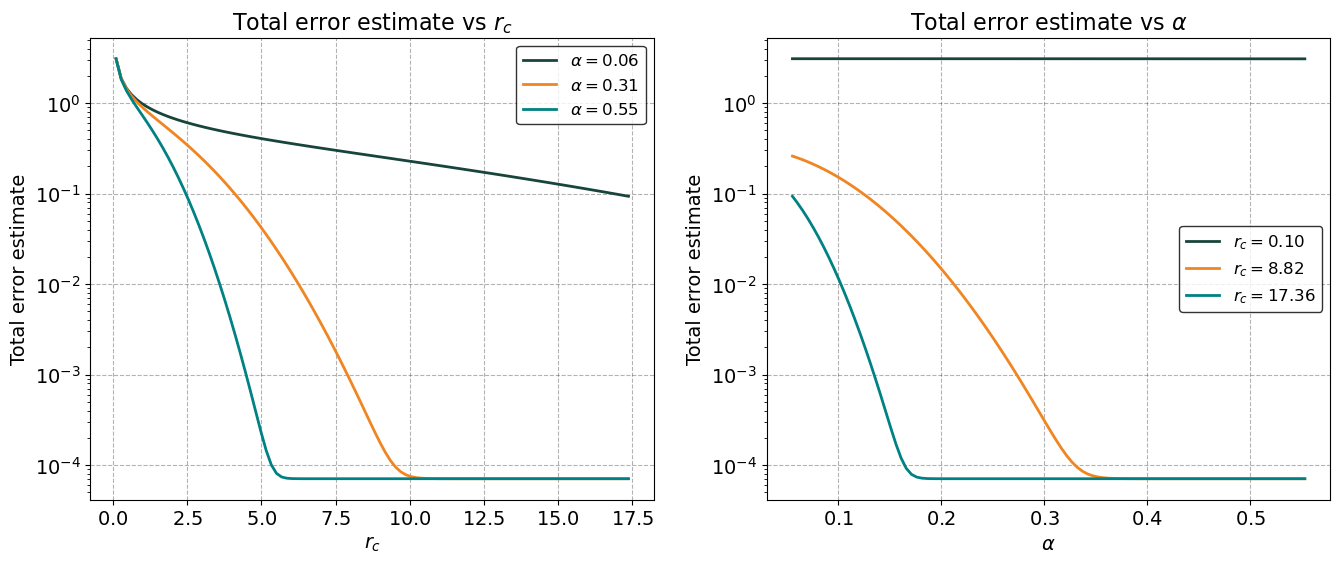

In [21]:
a_ws = 1.0   # Wigner-Seitz radius
# Rescale the PM error estimate
PM_err *= np.sqrt(total_num_ptcls) * a_ws**2 / np.sqrt(box_volume)
PM_err /= box_volume**(2/3)

rescaling_constant = np.sqrt(3.0/(4.0 * np.pi))

rc_values = np.linspace(0.1, L/2, 100)
alpha_values = np.linspace(0.2 * alpha, 2.0 * alpha, 100)
tot_err = np.zeros( (len(rc_values) , len(alpha_values) ) )

for ir, r_c in enumerate(rc_values):
    for ia, alpha_r in enumerate(alpha_values):
        PP_err = force_error_analytic_pp(cutoff_length=r_c, screening_parameter=0.0, alpha_ewald=alpha_r, rescaling_const=rescaling_constant)
        tot_err[ir, ia] = np.sqrt(PP_err**2 + PM_err**2)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
ax[0].plot(rc_values, tot_err[:, 0], label=rf"$\alpha = {alpha_values[0]:.2f}$")
ax[0].plot(rc_values, tot_err[:, 50], label=rf"$\alpha = {alpha_values[50]:.2f}$")
ax[0].plot(rc_values, tot_err[:, -1], label=rf"$\alpha = {alpha_values[-1]:.2f}$")
ax[0].set_xlabel(r"$r_c$", fontsize=14)
ax[0].set_ylabel("Total error estimate", fontsize=14)
ax[0].set_title("Total error estimate vs $r_c$", fontsize=16)
ax[0].legend(fontsize=12)
ax[0].set(yscale='log')
ax[0].grid(alpha=0.3)

ax[1].plot(alpha_values, tot_err[0, :], label=rf"$r_c = {rc_values[0]:.2f}$")
ax[1].plot(alpha_values, tot_err[50, :], label=rf"$r_c = {rc_values[50]:.2f}$")
ax[1].plot(alpha_values, tot_err[-1, :], label=rf"$r_c = {rc_values[-1]:.2f}$")
ax[1].set(yscale='log')
ax[1].set_xlabel(r"$\alpha$", fontsize=14)
ax[1].set_ylabel("Total error estimate", fontsize=14)
ax[1].set_title(r"Total error estimate vs $\alpha$", fontsize=16)
ax[1].legend(fontsize=12)
ax[1].grid(alpha=0.3)

print(f"PP error estimate: {PP_err:.6e}")
print(f"PM error estimate: {PM_err:.6e}")
print(f"Total error estimate: {np.sqrt(PP_err**2 + PM_err**2):.6e}")


In [22]:
# 3.5 - Calculate PP (short-range) interactions
print("\nCalculating PP (short-range) interactions...")
# RDF histogram (not used but needed for function call)
rdf_hist = np.zeros((2, 2, 100))
measure = False  # Don't measure RDF

# Calculate short-range potential and forces
pp_potential, pp_acc, virial_xx_pp, virial_yy_pp, virial_zz_pp, virial_xy_pp, virial_xz_pp, virial_yz_pp, j_e_pp  = pp_update(
    pos, vel, particle_ids, masses, box_lengths, rc, 
    potential_matrix, coulomb_force_pppm, measure, rdf_hist
)

# print("PP Potential energy of each particle:")
# for i, pot in enumerate(pp_potential):
#     print(f"  Particle {i+1}: {pot:.6e}")
print(f"Total PP potential energy: {np.sum(pp_potential):.6e}")


Calculating PP (short-range) interactions...
Total PP potential energy: 1.096123e+06


In [23]:
# Calculate PM (long-range) interactions
pm_potential, pm_acc, virial_xx_pm, virial_yy_pm, virial_zz_pm, virial_xy_pm, virial_xz_pm, virial_yz_pm = pm_update(
    pos, charges, masses, mesh_size, h_array, 
    mesh_volume, box_volume, G_k, kx_v, ky_v, kz_v, cao,
    vg0, vg1, vg2, vg3, vg4, vg5,
    fftw_objects
)
print(f"Total PM potential energy: {np.sum(pm_potential):.6e}")

# Ewald self-energy correction term
self_energy = -charges**2 * alpha / np.sqrt(np.pi) 
print(f"Total self-energy correction: {self_energy.sum():.6e}")

# Dipole correction
dipoles = charges[:, np.newaxis] * pos  # Dipole moment of each particle
net_dipole = dipoles.sum(axis=0)  # Net dipole moment of the system
dipole_correction = (net_dipole**2).sum(axis = -1)  * (2.0 * np.pi/ (3.0 * fourpie0 * box_volume ) )
print(f"Total dipole correction: {dipole_correction.sum():.6e}")

# Background charge correction (for non-neutral systems)
background_correction = - 0.0 * (charges.sum()**2) / (2 * fourpie0 * box_volume * alpha**2)
print(f"Total background charge correction: {background_correction:.6e}")

# Combine PP and PM results for total PPPM result
total_potential = pp_potential + pm_potential + background_correction/total_num_ptcls  + dipole_correction / total_num_ptcls# Distribute background correction equally among particles
total_potential_energy = np.sum(total_potential + self_energy)
print(f"Total system potential energy (with self-energy): {total_potential_energy:.6e}")

acc_tot = pp_acc + pm_acc
print(f"Acceleration on particle 1: {acc_tot[0, 0]:.6e}, {acc_tot[0, 1]:.6e}, {acc_tot[0, 2]:.6e}")
print(f"Acceleration on particle 2: {acc_tot[total_num_ptcls//2, 0]:.6e}, {acc_tot[total_num_ptcls//2, 1]:.6e}, {acc_tot[total_num_ptcls//2, 2]:.6e}")


Total PM potential energy: 4.978564e+01
Total self-energy correction: -3.898882e+03
Total dipole correction: 2.356092e+08
Total background charge correction: -0.000000e+00
Total system potential energy (with self-energy): 2.367014e+08
Acceleration on particle 1: -1.291356e+01, 1.753204e+00, 0.000000e+00
Acceleration on particle 2: -5.405507e+01, -5.522370e+01, 0.000000e+00


In [ ]:
# Analytical calculation of potential energy
import numba as nb

@nb.njit
def calculate_analytical_potential_energy(pos, charges, masses, box_lengths):
    # Calculate pairwise distances
    acc_analytic = np.zeros_like(pos)
    # Calculate the potential energy using the analytical formula
    U_analytical = 0.0
    for i in range(total_num_ptcls):
        for j in range(i+1, total_num_ptcls):
            dx = pos[i, 0] - pos[j, 0]
            dy = pos[i, 1] - pos[j, 1]
            # Apply minimum image convention for periodic boundaries
            dx -= box_lengths[0] * np.round(dx / box_lengths[0])
            dy -= box_lengths[1] * np.round(dy / box_lengths[1])
            distance_ij = np.sqrt(dx**2 + dy**2)

            U_analytical +=  charges[i] * charges[j] / distance_ij
            fr = charges[i] * charges[j] / distance_ij**2
            acc_analytic[i] += fr * (pos[i] - pos[j]) / distance_ij / masses[i]
            acc_analytic[j] += fr * (pos[j] - pos[i]) / distance_ij / masses[j]

    return U_analytical, acc_analytic

U_analytical, acc_analytic = calculate_analytical_potential_energy(pos, charges, masses, box_lengths)



In [ ]:
# Compare with PPPM result
print(f"Analytical potential energy: {U_analytical:.6e}")
print(f"Absolute ratio: {abs(U_analytical/total_potential_energy):.6e}")
print(f"Relative error: {100 * abs(1.0 - total_potential_energy / U_analytical):.4e}%")

# Compare accelerations
print(f"Analytical acceleration on particle 1: {acc_analytic[0, 0]:.6e}, {acc_analytic[0, 1]:.6e}, {acc_analytic[0, 2]:.6e}")
print(f"Analytical acceleration on particle 2: {acc_analytic[1, 0]:.6e}, {acc_analytic[1, 1]:.6e}, {acc_analytic[1, 2]:.6e}")